In [11]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(".."))
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path(os.path.abspath("."))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

In [12]:
RESEARCH_DATASET_DIR = (PROJECT_ROOT / "data" / "research_processed_smoke_auto").resolve()
RESEARCH_MODEL_DIR = (PROJECT_ROOT / "models" / "research_smoke_auto").resolve()
RESEARCH_RESULTS_DIR = (PROJECT_ROOT / "results" / "research_smoke_auto").resolve()

# 04 GPT

This notebook loads threshold-crossing anomaly candidates, builds compact GPT inputs, calls the OpenAI Responses API, parses structured JSON output, and compares AE-only vs AE+GPT decisions.

GPT is only used after anomaly score threshold crossing. The FiLM autoencoder remains the anomaly detector.

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

from src.config import GPTConfig
from src.gpt_adjudicator import (
    adjudicate_anomaly,
    adjudicate_anomaly_records,
    build_window_summary,
    call_openai_responses_api,
    compare_ae_vs_gpt_decisions,
)
from src.utils import read_json

## Load Anomalous Windows Or Evaluation Results

In [14]:
cfg = GPTConfig(
    evaluation_dir=RESEARCH_RESULTS_DIR,
    output_dir=RESEARCH_RESULTS_DIR,
    max_records=100,
)

alerts = pd.read_csv(cfg.evaluation_dir / "realtime_alert_candidates.csv")
alerts = alerts.sort_values("anomaly_score", ascending=False).reset_index(drop=True)
alerts.head()

,window_id,entity_id,container_id,machine_id,end_time,split,anomaly_score,threshold,score_over_threshold,feature_error_vector,...,predicted_label,event_id,realtime_step,alert_ready,gpt_triggered,gpt_label,gpt_severity,gpt_recommended_action,gpt_explanation,compact_anomaly_summary
0,440,c_10015,c_10015,m_3955,660290,test,15.401431,5.465899,9.935532,"[0.31295347213745117, 0.22800429165363312, 0.4...",...,1,-1,440,True,True,critical,high,raise_alert,The score is far above threshold and the highe...,"{""window_id"": 440, ""container_id"": ""c_10015"", ..."
1,281,c_10015,c_10015,m_3955,653460,test,15.385618,5.465899,9.919719,"[0.2918120324611664, 0.2618536055088043, 0.490...",...,1,-1,281,True,True,critical,high,raise_alert,The score is far above threshold and the highe...,"{""window_id"": 281, ""container_id"": ""c_10015"", ..."
2,378,c_10015,c_10015,m_3955,658190,test,15.344934,5.465899,9.879035,"[0.28003036975860596, 0.24915941059589386, 0.4...",...,1,-1,378,True,True,critical,high,raise_alert,The score is far above threshold and the highe...,"{""window_id"": 378, ""container_id"": ""c_10015"", ..."
3,554,c_10015,c_10015,m_3955,664440,test,15.281445,5.465899,9.815545,"[0.33049583435058594, 0.22353698313236237, 0.4...",...,1,-1,554,True,True,critical,high,raise_alert,The score is far above threshold and the highe...,"{""window_id"": 554, ""container_id"": ""c_10015"", ..."
4,1082,c_100,c_100,m_2664,683670,test,12.262834,5.465899,6.796934,"[1.3792273998260498, 0.012647528201341629, 0.5...",...,1,-1,1082,True,True,fault_candidate,medium,inspect_container,The anomaly is materially above threshold and ...,"{""window_id"": 1082, ""container_id"": ""c_100"", ""..."


## Build Compact GPT Input

In [15]:
sample_payload = alerts.iloc[0].to_dict() if len(alerts) > 0 else {}
sample_summary = build_window_summary(sample_payload) if sample_payload else {}
sample_summary

{'window_id': 440,
 'container_id': 'c_10015',
 'machine_id': 'm_3955',
 'split': 'test',
 'time_range': {'start_time': -1, 'end_time': 660290},
 'anomaly_score': 15.4014310836792,
 'threshold': 5.465899467468262,
 'score_over_threshold': 9.935531616210938,
 'top_k_features': ['mem_gps', 'mpki', 'disk_io', 'cpi', 'cpu_util'],
 'top_k_feature_errors': [117.78689575195312,
  3.6229658126831055,
  0.7433415651321411,
  0.4520427882671356,
  0.31295347213745117],
 'feature_error_vector': [0.31295347213745117,
  0.22800429165363312,
  0.4520427882671356,
  117.78689575195312,
  3.6229658126831055,
  0.019175881519913673,
  0.04607408866286278,
  0.7433415651321411],
 'context_summary': {'container_app_du': 'unknown',
  'container_status': 'unknown',
  'machine_status': 'unknown',
  'machine_failure_domain_1': 'unknown',
  'machine_failure_domain_2': 'unknown'},
 'recent_logs': [],
 'recent_events': []}

## Call OpenAI Responses API

In [16]:
if sample_summary:
    sample_decision, sample_meta = call_openai_responses_api(sample_summary, cfg)
else:
    sample_decision, sample_meta = {}, {}

sample_meta, sample_decision

({'used_fallback': True,
  'reason': 'openai_request_failed',
  'error': "Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}"},
 {'label': 'critical',
  'severity': 'high',
  'explanation': 'The score is far above threshold and the highest reconstruction errors are in mem_gps, mpki, disk_io. This is consistent with an active high-severity runtime issue.',
  'recommended_action': 'raise_alert'})

## Parse Structured JSON Output

In [17]:
sample_decision

{'label': 'critical',
 'severity': 'high',
 'explanation': 'The score is far above threshold and the highest reconstruction errors are in mem_gps, mpki, disk_io. This is consistent with an active high-severity runtime issue.',
 'recommended_action': 'raise_alert'}

## Compare AE-only Vs AE+GPT Decisions

In [18]:
adjudication_summary = adjudicate_anomaly_records(
    prediction_csv_path=cfg.evaluation_dir / "window_level_predictions.csv",
    config=cfg,
    max_records=cfg.max_records,
)
adjudication_summary

{'gpt_adjudications_csv': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\results\\research_smoke_auto\\gpt_adjudications.csv',
 'gpt_adjudications_json': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\results\\research_smoke_auto\\gpt_adjudications.json',
 'comparison_csv': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\results\\research_smoke_auto\\ae_vs_gpt_comparison.csv',
 'comparison_json': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\results\\research_smoke_auto\\ae_vs_gpt_comparison.json',
 'records': [{'window_id': 440,
   'entity_id': 'c_10015',
   'container_id': 'c_10015',
   'machine_id': 'm_3955',
   'end_time': 660290,
   'split': 'test',
   'anomaly_score': 15.4014310836792,
   'threshold': 5.465899467468262,
   'score_over_threshold': 9.935531616210938,
   'feature_error_vector': '[0.31295347213745117, 0.22800429165363312, 0.4520427882671356, 117.78689575195312, 3.6229658126831055, 0.019175881519913673, 0.04607408866286278, 0.7433415651321411]',
   'top_feature_rank': '[3

In [19]:
adjudications = pd.read_csv(cfg.output_dir / "gpt_adjudications.csv")
comparison = pd.read_csv(cfg.output_dir / "ae_vs_gpt_comparison.csv")

adjudications.head(), comparison.head()

(   window_id entity_id container_id machine_id  end_time split  anomaly_score  \
 0        440   c_10015      c_10015     m_3955    660290  test      15.401431   
 1        281   c_10015      c_10015     m_3955    653460  test      15.385618   
 2        378   c_10015      c_10015     m_3955    658190  test      15.344934   
 3        554   c_10015      c_10015     m_3955    664440  test      15.281445   
 4       1082     c_100        c_100     m_2664    683670  test      12.262834   
 
    threshold  score_over_threshold  \
 0   5.465899              9.935532   
 1   5.465899              9.919719   
 2   5.465899              9.879035   
 3   5.465899              9.815545   
 4   5.465899              6.796934   
 
                                 feature_error_vector  ... event_id  \
 0  [0.31295347213745117, 0.22800429165363312, 0.4...  ...       -1   
 1  [0.2918120324611664, 0.2618536055088043, 0.490...  ...       -1   
 2  [0.28003036975860596, 0.24915941059589386, 0.4...  ..

## Visualize GPT Decisions

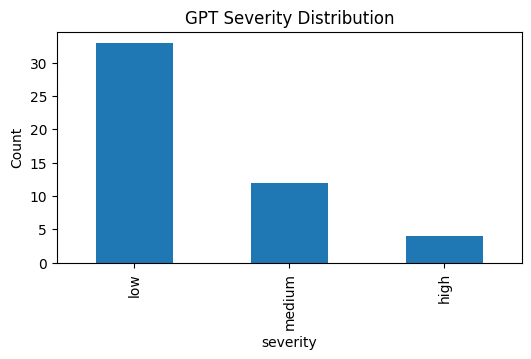

{'records': [{'window_id': 440,
   'container_id': 'c_10015',
   'machine_id': 'm_3955',
   'anomaly_score': 15.4014310836792,
   'ae_only_label': 'fault_candidate',
   'gpt_label': 'critical',
   'severity': 'high',
   'recommended_action': 'raise_alert',
   'explanation': 'The score is far above threshold and the highest reconstruction errors are in mem_gps, mpki, disk_io. This is consistent with an active high-severity runtime issue.'},
  {'window_id': 281,
   'container_id': 'c_10015',
   'machine_id': 'm_3955',
   'anomaly_score': 15.385618209838867,
   'ae_only_label': 'fault_candidate',
   'gpt_label': 'critical',
   'severity': 'high',
   'recommended_action': 'raise_alert',
   'explanation': 'The score is far above threshold and the highest reconstruction errors are in mem_gps, mpki, disk_io. This is consistent with an active high-severity runtime issue.'},
  {'window_id': 378,
   'container_id': 'c_10015',
   'machine_id': 'm_3955',
   'anomaly_score': 15.344934463500977,
   

In [20]:
if len(adjudications) > 0:
    plt.figure(figsize=(6, 3))
    adjudications["severity"].value_counts().plot(kind="bar")
    plt.title("GPT Severity Distribution")
    plt.ylabel("Count")
    plt.show()

read_json(cfg.output_dir / "ae_vs_gpt_comparison.json")